# Two coupled layers

Relax two layers from random spins with an interlayer coupling field `H_RKKY`. A positive value favours antiparallel layers, a negative value parallel ones. No demag.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skyrmion_simulator.simulator.params_helper import make_params
from skyrmion_simulator.simulator.pulses import ConstantPulse
mu0 = 4.0e-7 * np.pi
from skyrmion_simulator.simulator.relaxation import relax

In [2]:
a, nx, K = 2.0e-9, 32, 1.6e6
rng = np.random.default_rng(0)


def random_spins():
    """Unit vectors with random orientation, shape (nx, nx, 3)."""
    m = rng.normal(size=(nx, nx, 3))
    return m / np.linalg.norm(m, axis=-1, keepdims=True)


results = {}
for H_RKKY in (+0.2, -0.2):
    p = make_params(nx=nx, ny=nx, a=a, D=0.0, K_top=K, K_bot=K,
                    alpha=1.0, H_RKKY=H_RKKY, H_ext=np.zeros(3),
                    dt=5.0e-14, pulse=ConstantPulse(0.0))
    m_top, m_bot, converged, n_steps, _, _ = relax(
        random_spins(), random_spins(), p, None, max_steps=100000,
        tol_torque=1.0e-4, check_every=500)
    dot = np.mean(np.sum(m_top * m_bot, axis=-1))
    print(f'H_RKKY = {H_RKKY:+.1f} T: converged={converged}, '
          f'<m_top . m_bot> = {dot:+.3f}')
    results[H_RKKY] = (m_top, m_bot)

H_RKKY = +0.2 T: converged=True, <m_top . m_bot> = -1.000


H_RKKY = -0.2 T: converged=True, <m_top . m_bot> = +1.000


The single-layer solver is the same code with `None` as the partner layer; `H_RKKY` is then ignored.

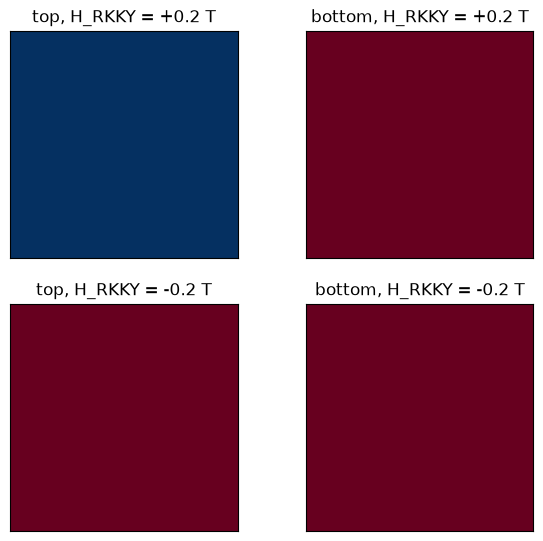

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(7, 6.5))
for row, H_RKKY in zip(axes, (+0.2, -0.2)):
    for ax, m, name in zip(row, results[H_RKKY], ('top', 'bottom')):
        ax.imshow(m[..., 2], origin='lower', cmap='RdBu_r', vmin=-1, vmax=1)
        ax.set_title(f'{name}, H_RKKY = {H_RKKY:+.1f} T')
        ax.set_xticks([])
        ax.set_yticks([])
plt.show()